In [2]:
import os
import math
import json
import warnings
import itertools
from datetime import datetime

warnings.filterwarnings("ignore")

In [3]:
os.environ.setdefault("FINTORCH_BASE_TIME_FRAME", "60")

'60'

In [4]:
import numpy as np 
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from fintorch.enum import TimeFrame
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.preprocess import remove_price_dependency
from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import draw_candlestick_plot, draw_labels, draw_predictions

In [5]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
    "--time-frame", "60",
    "--symbol", "BTC-USDT"
]

args = DefaultArgumentParser.parse(args=string_args)

In [6]:
sdf = ONLINE_EXCHANGE.future.data.update_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame)
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame).copy()
sdf.insert(0, "datetime", [datetime.fromtimestamp(ts) for ts in sdf.index])

sdf

,datetime,open,high,low,close,volume,trade
timestamp,,,,,,,
1705395660,2024-01-16 12:31:00,43032.7,43040.0,42985.6,43003.7,201.772,3323
1705395720,2024-01-16 12:32:00,43004.5,43016.0,42960.0,42967.3,534.556,4093
1705395780,2024-01-16 12:33:00,42967.3,42976.5,42954.2,42957.8,117.148,1847
1705395840,2024-01-16 12:34:00,42957.9,42965.7,42928.9,42942.2,245.105,3502
1705395900,2024-01-16 12:35:00,42942.3,42953.0,42919.0,42942.6,134.988,1928
...,...,...,...,...,...,...,...
1712169720,2024-04-03 22:12:00,65844.6,65857.7,65818.3,65854.4,147.168,2016
1712169780,2024-04-03 22:13:00,65854.4,65857.5,65802.5,65802.6,114.494,1750
1712169840,2024-04-03 22:14:00,65802.6,65870.9,65802.6,65870.9,134.974,1793


In [7]:
WINDOW = 11

df = sdf.copy()
# df = remove_price_dependency(df=df.copy())
# df = np.round(df, 6)

df["roc"] = df.close / df.open - 1
df["aroc"] = np.abs(df.roc).rolling(window=10).mean()

df["cmax"] = df.close.rolling(window=WINDOW, min_periods=1, center=True).max()
df["cmin"] = df.close.rolling(window=WINDOW, min_periods=1, center=True).min()
df["isfh"] = df.close == df.cmax
df["isfl"] = df.close == df.cmin
df["isf"] = df.isfh | df.isfl
df = df.dropna()

df["fractal"] = df.close[df.isf]


df

,datetime,open,high,low,close,volume,trade,roc,aroc,cmax,cmin,isfh,isfl,isf,fractal
timestamp,,,,,,,,,,,,,,,
1705396200,2024-01-16 12:40:00,42961.5,42970.2,42910.9,42921.0,108.129,1524,-0.000943,0.000479,42970.5,42903.5,False,False,False,NaN
1705396260,2024-01-16 12:41:00,42921.1,42952.9,42910.0,42950.5,144.802,1678,0.000685,0.000480,42970.5,42903.5,False,False,False,NaN
1705396320,2024-01-16 12:42:00,42950.5,42954.9,42928.1,42949.3,100.250,1747,-0.000028,0.000396,42970.5,42903.5,False,False,False,NaN
1705396380,2024-01-16 12:43:00,42949.2,42949.2,42925.4,42927.7,46.979,1289,-0.000501,0.000424,42998.5,42903.5,False,False,False,NaN
1705396440,2024-01-16 12:44:00,42927.7,42939.4,42899.6,42903.5,249.853,2298,-0.000564,0.000444,43037.4,42903.5,False,True,True,42903.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712169720,2024-04-03 22:12:00,65844.6,65857.7,65818.3,65854.4,147.168,2016,0.000149,0.000591,65880.0,65799.9,False,False,False,NaN
1712169780,2024-04-03 22:13:00,65854.4,65857.5,65802.5,65802.6,114.494,1750,-0.000787,0.000579,65880.0,65799.9,False,False,False,NaN
1712169840,2024-04-03 22:14:00,65802.6,65870.9,65802.6,65870.9,134.974,1793,0.001038,0.000618,65880.0,65799.9,False,False,False,NaN


In [40]:
def find_price_levels(df):
    x = df.fractal.dropna().to_numpy().reshape(-1, 1)
    model = KMeans(n_clusters=8, random_state=0, n_init="auto").fit(x)
    return model.cluster_centers_.reshape(-1)


def find_(df):
    price = df.close.iloc[-1]
    levels = find_price_levels(df=df)
    below_levels = levels[levels < price]
    if 0 < len(below_levels):
        return below_levels.max()

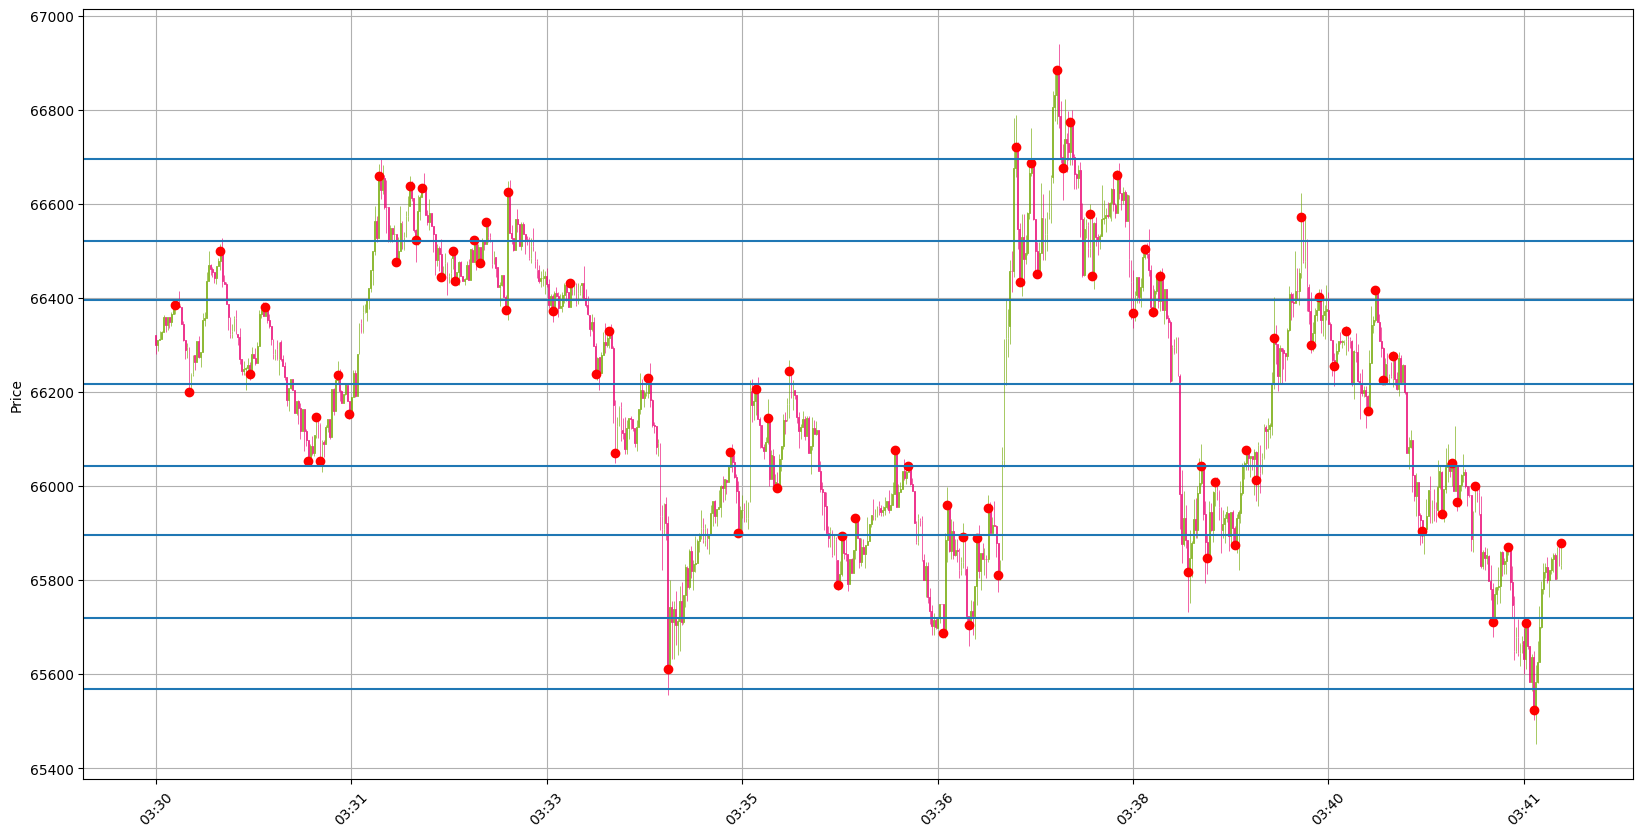

In [41]:
pdf = df[-720:]
pdf = pdf.reset_index()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))
ax.grid()

draw_candlestick_plot(ax=ax, df=pdf)
ax.plot(pdf.fractal[pdf.isf], "ro")

for price_level in find_price_levels(df=pdf):
    ax.axhline(price_level) 

In [48]:
DEBUG = False
LOOKBACK = 1440
TPM = 1
SLM = 100
VAR = 0.1

bars_list = []
profits_list = []
leverages_list = []

order_index, order_price = None, None
entry_index, entry_price = None, None
for index in tqdm(range(LOOKBACK, len(df))):
    if DEBUG:
        o = df.open.iloc[index]
        h = df.high.iloc[index]
        l = df.low.iloc[index]
        c = df.close.iloc[index]
        print("{} {} {} {} {}".format(df.datetime.iloc[index], o, h, l, c))
    
    if entry_index is None:
        # reset order 
        if order_index is not None and 60 < index - order_index:
            order_index = None
            order_price = None

            if DEBUG:
                print("{:<64} Reset order".format(str(df.datetime.iloc[index])))

        # set order
        if order_index is None:
            bdf = df.iloc[index - LOOKBACK: index]
            price_level = find_price_level(df=bdf)
            if price_level is not None:
                order_index = index
                order_price = round(price_level, 2)

                if DEBUG:
                    print("{:<64} Set new order {}".format(str(df.datetime.iloc[index]), order_price))

        # check for fill condition
        if order_index is not None and df.low.iloc[index] <= order_price <= df.high.iloc[index]:
            entry_index = index
            entry_price = order_price
            
            volatility = round(df.aroc.iloc[index], 4)
            take_profit_rate = round(volatility * TPM, 4)
            stop_loss_rate = round(volatility * SLM, 4)

            leverage = VAR // stop_loss_rate
            leverage = max(1, leverage)
            leverage = min(leverage, 100)
            
            take_profit_price = round(entry_price * (1 + take_profit_rate), 2)
            stop_loss_price = round(entry_price * (1 - stop_loss_rate), 2)

            order_price = None
            order_index = None
            
            if DEBUG:
                print("{:<64} Entry Position VOL/TPR/SLR/LVG {}/{}/{}/{} EN/TP/SL {}/{}/{}"
                      .format(str(df.datetime.iloc[index]), volatility, take_profit_rate, stop_loss_rate, leverage, entry_price, take_profit_price, stop_loss_price))
            
    if entry_index is not None:
        exit_price = None
        if df.low.iloc[index] <= stop_loss_price:
            exit_price = stop_loss_price
            fee = 0.001
        elif take_profit_price < df.high.iloc[index]:
            exit_price = take_profit_price
            fee = 0.0005
        
        if exit_price is not None:
            bars = index - entry_index
            realized_profit = round(exit_price / entry_price - 1, 4)
            profit = round((realized_profit - fee) * leverage, 4)
            
            bars_list.append(bars)
            profits_list.append(profit)
            leverages_list.append(leverage)

            entry_index = None
            entry_price = None
            
            if DEBUG:
                print("{:<64} Exit position RPNL/Profit/Bars {}/{}/{}".format(str(df.datetime.iloc[index]), realized_profit, profit, bars))
                print("=" * 64)
                print()

        if DEBUG and 10 == len(profits_list):
            break 

  0%|          | 0/111457 [00:00<?, ?it/s]

In [49]:
bars = np.array(bars_list)
profits = np.array(profits_list)
leverages = np.array(leverages_list)

days = len(df) * TimeFrame.MIN1 // TimeFrame.DAY1

min_bars = bars.min()
max_bars = bars.max()
mean_bars = bars.mean()

trades = len(profits)
daily_trades = len(profits) // days

mean_leverage = round(leverages.mean(), 2)

net_profit = profits.sum()
compound_profit = (1 + profits).prod() - 1
daily_net_profit = net_profit / days
daily_compound_profit = (compound_profit + 1) ** (1 / days) - 1

wining_ratio = (0 < profits).sum() / len(profits) * 100

# print statements
print("{:<32}{}".format("Days", days))
print()
print("{:<32}{}".format("Min bars", min_bars))
print("{:<32}{:}".format("Max bars", max_bars))
print("{:<32}{:.2f}".format("Mean bars", mean_bars))
print()
print("{:<32}{}".format("Trades", trades))
print("{:<32}{}".format("Daily trades", daily_trades))
print()
print("{:<32}{}".format("Mean Leverage", mean_leverage))
print()
print("{:<32}{:.2f}".format("Net profit", net_profit))
print("{:<32}{:.2f}".format("Compound profit", compound_profit))
print("{:<32}{:.2f}".format("Daily net profit", daily_net_profit))
print("{:<32}{:.2f}".format("Daily compound profit", daily_compound_profit))
print()
print("{:<32}{:.2f}%".format("Wining ratio", wining_ratio))

Days                            78

Min bars                        0
Max bars                        7200
Mean bars                       30.66

Trades                          1521
Daily trades                    19

Mean Leverage                   2.37

Net profit                      -0.99
Compound profit                 -0.64
Daily net profit                -0.01
Daily compound profit           -0.01

Wining ratio                    37.02%


In [50]:
profits

array([-0.0002, -0.0015,  0.0001, ...,  0.    ,  0.0002,  0.0003])